<!-- launch-badges -->
<a href="https://colab.research.google.com/github/laban254/ml-for-infrastructure/blob/main/05_sre_applications/anomaly_detection/prometheus_anomaly.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
&nbsp;
<a href="https://mybinder.org/v2/gh/laban254/ml-for-infrastructure/main?urlpath=lab/tree/05_sre_applications/anomaly_detection/prometheus_anomaly.ipynb" target="_blank"><img src="https://mybinder.org/badge_logo.svg" alt="Open in Binder"/></a>

> ▶️ **Run this notebook live** — no install needed. Click a badge above to open it in a free cloud runtime.

# Anomaly Detection in Infrastructure Metrics

## Objectives
- Understand how to frame an unsupervised anomaly detection problem for time-series infrastructure data.
- Implement an **Isolation Forest** to identify spikes or drops in CPU/Memory usage.
- Use **Z-Score** statistical methods for simpler, threshold-based alerting.

## Dataset
- We will generate continuous, synthetic "Prometheus-style" time series data representing server CPU utilization over 7 days, complete with weekly seasonality, background noise, and injected anomalies.

## Expected Outcome
- A visualization distinguishing normal operational behavior from anomalous spikes.
- A simple function that accepts a new data point and returns whether it should trigger an alert.

## Challenge
- Tune the `contamination` parameter of the Isolation Forest. How does changing it impact the false-positive rate of your alerts?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

# Set random state for reproducibility
np.random.seed(42)
sns.set_theme(style="darkgrid")

### 1. Generating Synthetic Prometheus Data
Real infrastructure metrics have seasonality (people sleep at night) and noise.

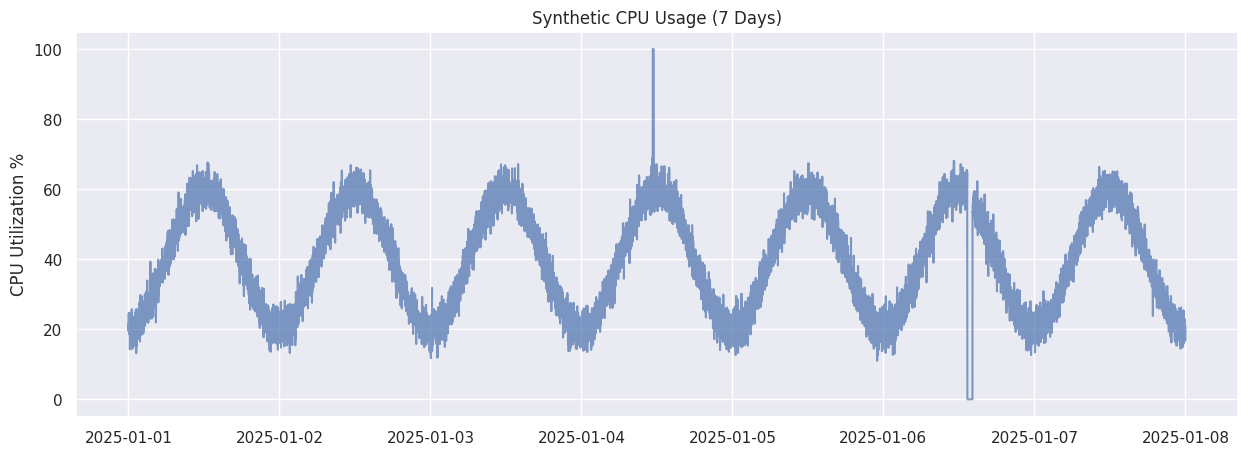

In [2]:
def generate_cpu_metrics(days=7, points_per_hour=60):
    total_points = days * 24 * points_per_hour
    t = np.linspace(0, days * 2 * np.pi, total_points)
    
    # Base daily sine wave (peaking in middle of day)
    base_load = 40 + 20 * np.sin(t - (np.pi/2))
    
    # Add noise
    noise = np.random.normal(0, 3, total_points)
    
    # Combine
    cpu_usage = base_load + noise
    
    # Inject Anomalies
    # 1. Sudden massive spike
    cpu_usage[5000:5010] += 45
    # 2. Complete drop (service down)
    cpu_usage[8000:8050] = 0
    
    # Create DataFrame
    df = pd.DataFrame({
        'timestamp': pd.date_range(start='2025-01-01', periods=total_points, freq='1min'),
        'cpu_usage': np.clip(cpu_usage, 0, 100) # CPU can't go below 0 or above 100
    })
    return df

df = generate_cpu_metrics()

plt.figure(figsize=(15, 5))
plt.plot(df['timestamp'], df['cpu_usage'], alpha=0.7)
plt.title("Synthetic CPU Usage (7 Days)")
plt.ylabel("CPU Utilization %")
plt.show()

### 2. Isolation Forest
Isolation Forest is great for multidimensional data or data that isn't perfectly normally distributed. It "isolates" anomalies by randomly partitioning the data; anomalies are easier to isolate (require fewer partitions) than normal points.

In [3]:
# We expect roughly 1% of our data to be anomalous
model = IsolationForest(contamination=0.01, random_state=42)

# Fit the model (unsupervised, so we don't pass labels)
# Must reshape data to 2D array for sklearn
df['anomaly_iforest'] = model.fit_predict(df[['cpu_usage']])

# Isolation forest returns -1 for anomaly, 1 for normal.
# Let's map it to True/False for easier plotting
df['is_anomaly'] = df['anomaly_iforest'] == -1

print(f"Detected {df['is_anomaly'].sum()} anomalies out of {len(df)} points.")

Detected 100 anomalies out of 10080 points.


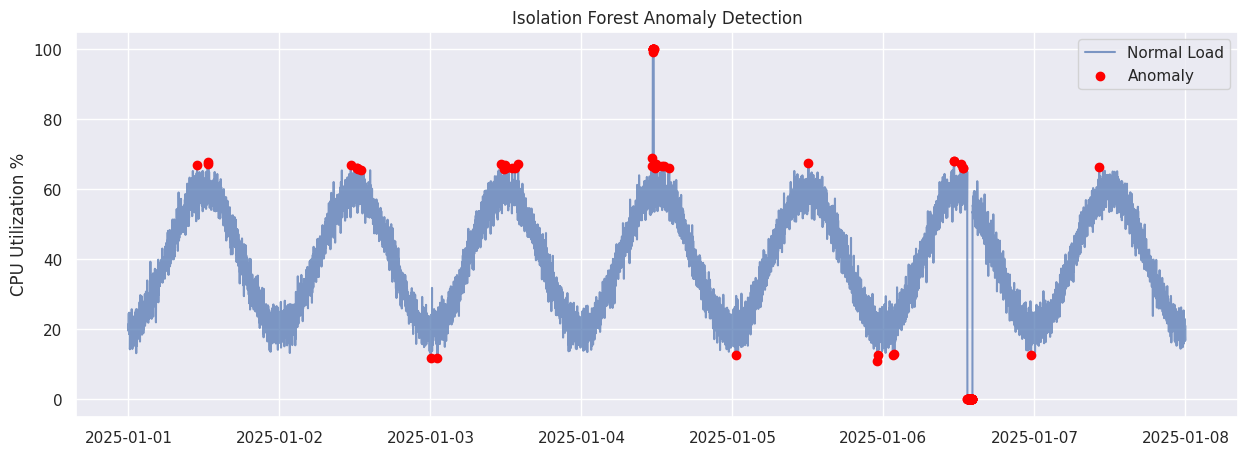

In [4]:
plt.figure(figsize=(15, 5))
plt.plot(df['timestamp'], df['cpu_usage'], alpha=0.7, label='Normal Load')

# Highlight anomalies
anomalies = df[df['is_anomaly']]
plt.scatter(anomalies['timestamp'], anomalies['cpu_usage'], color='red', label='Anomaly', zorder=5)

plt.title("Isolation Forest Anomaly Detection")
plt.ylabel("CPU Utilization %")
plt.legend()
plt.show()

---
## 🧪 Try it yourself: tune the alert sensitivity

`contamination` tells Isolation Forest what fraction of points it should treat as anomalies. Too high and you drown in false alerts (**alert fatigue**); too low and you miss real outages. Drag the slider and watch the trade-off.

> 💡 Runs live in Colab/Binder. On GitHub you see the default (1%) rendering.

In [5]:
from ipywidgets import interact, FloatSlider

def detect(contamination=0.01):
    model = IsolationForest(contamination=contamination, random_state=42)
    flags = model.fit_predict(df[['cpu_usage']]) == -1
    plt.figure(figsize=(15, 4))
    plt.plot(df['timestamp'], df['cpu_usage'], alpha=0.6, label='CPU Load')
    plt.scatter(df['timestamp'][flags], df['cpu_usage'][flags],
                color='red', zorder=5, label=f'{flags.sum()} anomalies')
    plt.title(f'Isolation Forest — contamination = {contamination:.3f}')
    plt.ylabel('CPU Utilization %'); plt.legend(); plt.show()

interact(detect, contamination=FloatSlider(
    min=0.001, max=0.05, step=0.001, value=0.01, readout_format='.3f'));

interactive(children=(FloatSlider(value=0.01, description='contamination', max=0.05, min=0.001, readout_format…

## 📝 Exercise: a simple Z-score detector

Isolation Forest is powerful but opaque. Many on-call alerts are still plain statistics. **Flag every point whose Z-score is greater than 3** (i.e. more than 3 standard deviations from the mean) and compare the count to Isolation Forest's. Which fires more? Which would you trust at 3 a.m.?

```python
# your code here
# hint: z = (df['cpu_usage'] - mean) / std
```

<details><summary>💡 Reveal solution</summary>

```python
mu, sigma = df['cpu_usage'].mean(), df['cpu_usage'].std()
df['z'] = (df['cpu_usage'] - mu) / sigma
z_flags = df['z'].abs() > 3
print(f"Z-score flagged {z_flags.sum()} points")
print(f"Isolation Forest flagged {df['is_anomaly'].sum()} points")
```

The Z-score method is blind to seasonality — it will miss a spike that is still below the global mean+3σ during a busy period. That is exactly why we reach for Isolation Forest on real telemetry.
</details>